In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv
from sklearn.preprocessing import StandardScaler

In [2]:
# get demand data from NTUST (sum from multiple building in NTUST)
power_df = pd.read_csv("../dataset/NTUST.csv", index_col=0, parse_dates=True)
power_df = power_df.asfreq('h') 
power_df = pd.DataFrame(power_df.loc[power_df.index.year!=2020, "KW"].round(2).copy())

In [3]:
power_df.head()

,KW
timestamp,
2019-01-23 00:00:00,359.32
2019-01-23 01:00:00,308.63
2019-01-23 02:00:00,284.17
2019-01-23 03:00:00,252.00
2019-01-23 04:00:00,263.33


In [4]:
power_df.tail()

,KW
timestamp,
2019-12-31 19:00:00,416.52
2019-12-31 20:00:00,413.42
2019-12-31 21:00:00,399.26
2019-12-31 22:00:00,387.49
2019-12-31 23:00:00,353.23


In [5]:
weather_df = pd.read_csv("../dataset/NSRDB.csv")
weather_df.index = power_df.index 

In [6]:
weather_df.head()

,YEAR,MONTH,DAY,HOUR,TEMPERATURE,DEW_POINT,GHI,PRESSURE,WIND_SPEED,RELATIVE HUMIDITY,PRECIPITABLE WATER,CLOUD_TYPE
timestamp,,,,,,,,,,,,
2019-01-23 00:00:00,2019,1,23,0,14.3,8.8,0,1032,4.1,69.69,1.4,0
2019-01-23 01:00:00,2019,1,23,1,14.2,8.8,0,1031,4.1,70.21,1.4,3
2019-01-23 02:00:00,2019,1,23,2,14.1,8.9,0,1031,4.1,71.05,1.4,3
2019-01-23 03:00:00,2019,1,23,3,14.1,9.0,0,1031,4.1,71.62,1.4,0
2019-01-23 04:00:00,2019,1,23,4,14.1,9.2,0,1031,4.0,72.27,1.4,3


In [7]:
weather_df.tail()

,YEAR,MONTH,DAY,HOUR,TEMPERATURE,DEW_POINT,GHI,PRESSURE,WIND_SPEED,RELATIVE HUMIDITY,PRECIPITABLE WATER,CLOUD_TYPE
timestamp,,,,,,,,,,,,
2019-12-31 19:00:00,2019,12,31,19,16.3,12.7,0,1039,6.6,79.46,2.6,3
2019-12-31 20:00:00,2019,12,31,20,16.3,12.8,0,1039,6.5,79.67,2.6,3
2019-12-31 21:00:00,2019,12,31,21,16.3,12.9,0,1039,6.3,80.06,2.5,3
2019-12-31 22:00:00,2019,12,31,22,16.3,13.0,0,1039,6.1,80.74,2.4,3
2019-12-31 23:00:00,2019,12,31,23,16.3,13.1,0,1038,6.0,81.17,2.4,3


In [8]:
weather_df = weather_df.drop(columns=['YEAR', 'MONTH', 'DAY', 'HOUR'])

In [9]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8232 entries, 2019-01-23 00:00:00 to 2019-12-31 23:00:00
Freq: h
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   TEMPERATURE         8232 non-null   float64
 1   DEW_POINT           8232 non-null   float64
 2   GHI                 8232 non-null   int64  
 3   PRESSURE            8232 non-null   int64  
 4   WIND_SPEED          8232 non-null   float64
 5   RELATIVE HUMIDITY   8232 non-null   float64
 6   PRECIPITABLE WATER  8232 non-null   float64
 7   CLOUD_TYPE          8232 non-null   int64  
dtypes: float64(5), int64(3)
memory usage: 578.8 KB


In [10]:
print(weather_df.shape)
print(power_df.shape)

(8232, 8)
(8232, 1)


/var/folders/97/8bx4_dmx3038pm1qrblmtrl80000gn/T/ipykernel_19932/4146627371.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = power_df.resample('M').mean()


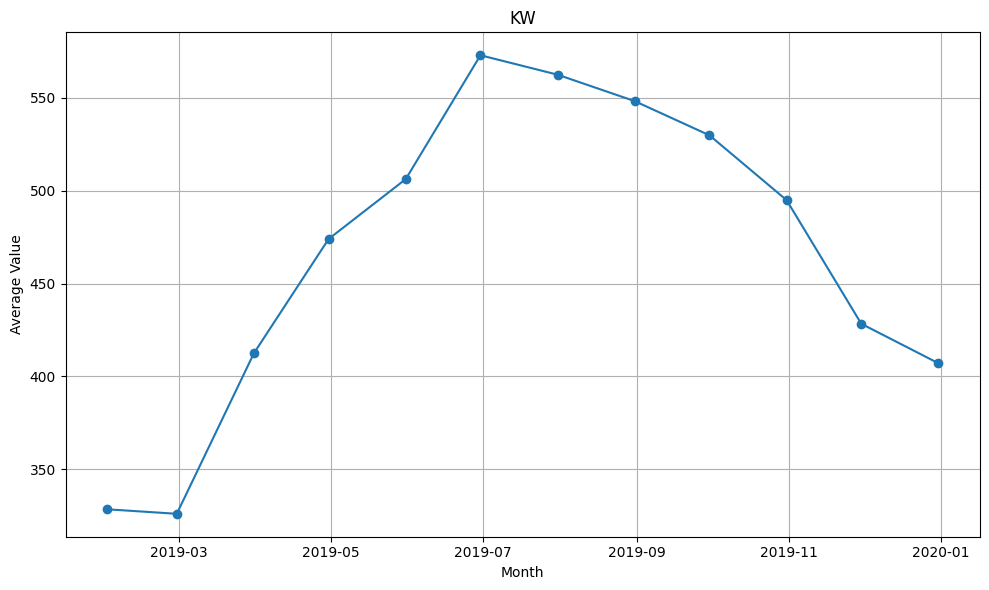

In [12]:
power_df.index = pd.to_datetime(power_df.index)

# Resample data menjadi rata-rata bulanan
monthly_data = power_df.resample('M').mean()

# Setup plot tunggal
plt.figure(figsize=(10, 6))
plt.plot(monthly_data.index, monthly_data["KW"], marker='o', linestyle='-')
plt.title("KW")
plt.xlabel("Month")
plt.ylabel("Average Value")
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/97/8bx4_dmx3038pm1qrblmtrl80000gn/T/ipykernel_19932/1267940517.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = weather_df.resample('M').mean()


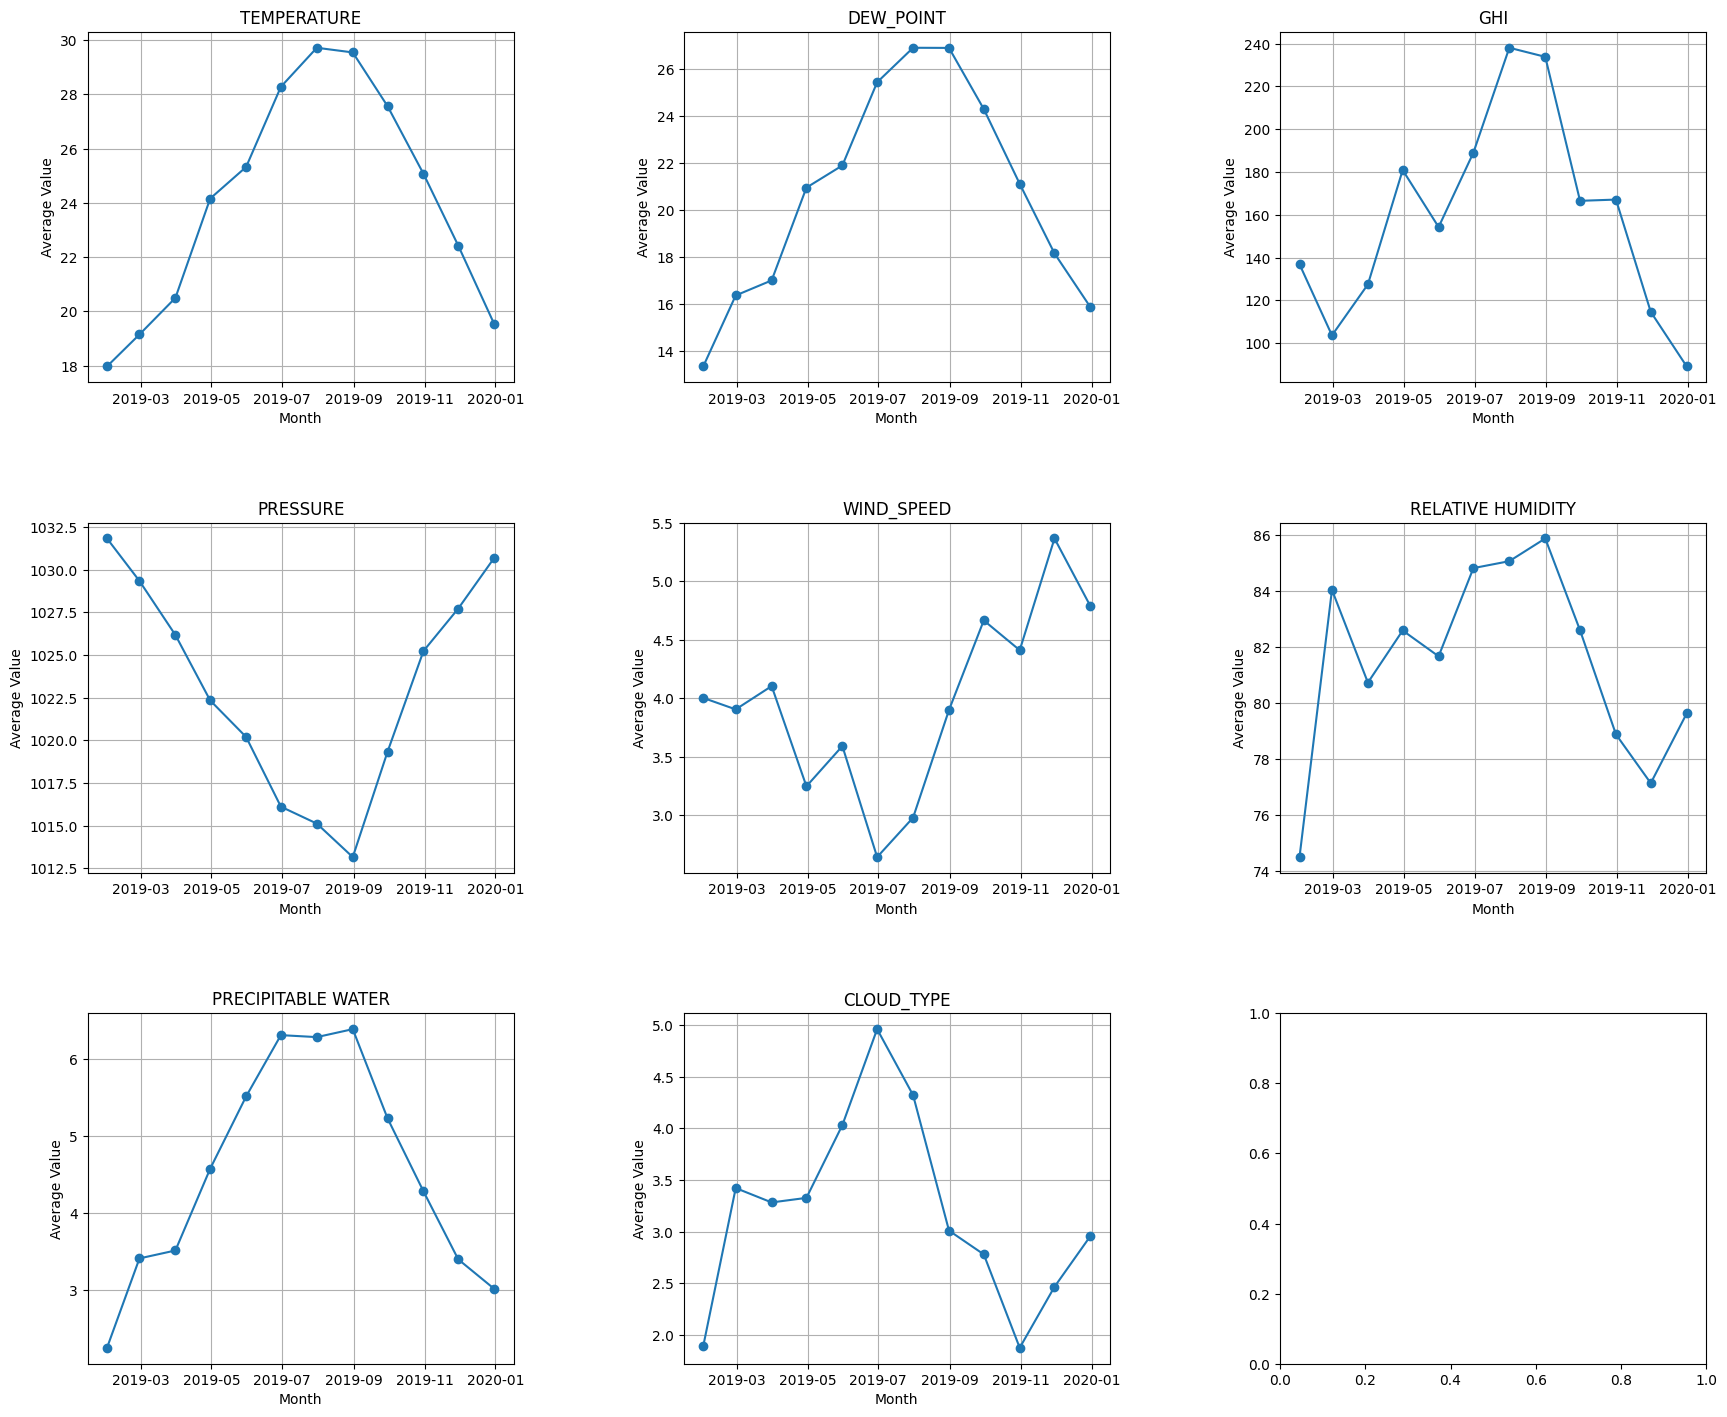

In [14]:
# Pastikan index sudah dalam format datetime
weather_df.index = pd.to_datetime(weather_df.index)

# Resampling data per bulan dengan rata-rata
monthly_data = weather_df.resample('M').mean()

# Setup plot
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
fig.tight_layout(pad=5.0)

# Kolom-kolom yang akan diplot
columns = [
    'TEMPERATURE',
    'DEW_POINT',
    'GHI',
    'PRESSURE',
    'WIND_SPEED',
    'RELATIVE HUMIDITY',
    'PRECIPITABLE WATER',
    'CLOUD_TYPE'
]

# Loop untuk plotting setiap fitur
for i, column in enumerate(columns):
    ax = axes[i // 3, i % 3]
    ax.plot(monthly_data.index, monthly_data[column], marker='o', linestyle='-')
    ax.set_title(column)
    ax.set_xlabel('Month')
    ax.set_ylabel('Average Value')
    ax.grid(True)

# Adjust space between plots
plt.subplots_adjust(hspace=0.4, wspace=0.4)

# Tampilkan plot
plt.show()
